# Классификация автомобилей: [Stanford Cars 196](https://www.kaggle.com/datasets/eduardo4jesus/stanford-cars-dataset/data)

## Теория и принципиальные решения

Это задача многоклассовой классификации: для изображения $x$ модель возвращает вектор вероятностей $p(y \mid x)$ по всем классам. В качестве основной метрики используем **top-1 accuracy**, а **top-5 accuracy** оставляем дополнительной: визуально похожие модели автомобилей часто трудно различить даже человеку.

Мы используем transfer learning с [EfficientNetB0](https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0). Предобученная свёрточная сеть уже извлекает универсальные визуальные признаки, поэтому сначала замораживаем backbone(сохраняем текущие веса модели с целью не сломать модель новым обучением). Затем осторожно размораживаем последние слои и делаем fine-tuning с маленьким learning rate. Это уменьшает риск разрушить полезные ImageNet-признаки и снижает вычислительную стоимость.

Разметка Stanford Cars содержит bounding box. Для обучения используем crop автомобиля с небольшим контекстным полем: так модель меньше отвлекается на фон, но сохраняет части кузова, помогающие распознаванию.

## 1. Импорты и конфигурация

Все параметры эксперимента собраны в `ExperimentConfig`. Это делает запуск повторяемым и позволяет менять датасет, размеры выборок, augmentation и обучение в одном месте.

Важно: изображения остаются в диапазоне `0..255`. В сохранённой EfficientNet уже есть встроенный preprocessing/rescaling, поэтому дополнительное деление на `255` здесь запрещено: двойная нормализация меняет распределение входов и ухудшает предсказания.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import json
import random

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from scipy.io import loadmat
from sklearn.model_selection import train_test_split


@dataclass(frozen=True)
class ExperimentConfig:
    dataset_slug: str = "eduardo4jesus/stanford-cars-dataset"
    image_height: int = 224
    image_width: int = 224
    channels: int = 3
    batch_size: int = 32
    random_seed: int = 42
    validation_fraction: float = 0.20
    test_fraction_of_remaining: float = 0.50
    bbox_margin_fraction: float = 0.05
    head_epochs: int = 12
    fine_tune_epochs: int = 8
    fine_tune_layer_count: int = 30
    head_learning_rate: float = 1e-3
    fine_tune_learning_rate: float = 1e-5
    dropout_rate: float = 0.35
    rotation_factor: float = 0.04
    zoom_height_range: tuple[float, float] = (-0.05, 0.10)
    zoom_width_range: tuple[float, float] = (-0.05, 0.10)
    contrast_factor: float = 0.15
    reduce_lr_factor: float = 0.3
    reduce_lr_patience: int = 2
    head_patience: int = 4
    fine_tune_patience: int = 3
    head_min_learning_rate: float = 1e-6
    fine_tune_min_learning_rate: float = 1e-7
    confidence_threshold: float = 0.60
    margin_threshold: float = 0.10
    top_k: int = 5
    output_directory: Path = Path("artifacts")


CONFIG = ExperimentConfig()
IMAGE_SIZE = (CONFIG.image_height, CONFIG.image_width)
AUTOTUNE = tf.data.AUTOTUNE

random.seed(CONFIG.random_seed)
np.random.seed(CONFIG.random_seed)
tf.random.set_seed(CONFIG.random_seed)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print(CONFIG)

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
ExperimentConfig(dataset_slug='eduardo4jesus/stanford-cars-dataset', image_height=224, image_width=224, channels=3, batch_size=32, random_seed=42, validation_fraction=0.2, test_fraction_of_remaining=0.5, bbox_margin_fraction=0.05, head_epochs=12, fine_tune_epochs=8, fine_tune_layer_count=30, head_learning_rate=0.001, fine_tune_learning_rate=1e-05, dropout_rate=0.35, rotation_factor=0.04, zoom_height_range=(-0.05, 0.1), zoom_width_range=(-0.05, 0.1), contrast_factor=0.15, reduce_lr_factor=0.3, reduce_lr_patience=2, head_patience=4, fine_tune_patience=3, head_min_learning_rate=1e-06, fine_tune_min_learning_rate=1e-07, confidence_threshold=0.6, margin_threshold=0.1, top_k=5, output_directory=PosixPath('artifacts'))


In [2]:
dataset_root = Path(kagglehub.dataset_download(CONFIG.dataset_slug))
devkit_directory = next(dataset_root.glob("**/cars_train_annos.mat")).parent
train_images_directory = next(
directory for directory in dataset_root.glob("**/cars_train")
    if directory.is_dir() and any(directory.glob("*.jpg"))
)

print("Dataset:", dataset_root)
print("Devkit:", devkit_directory)
print("Train images:", train_images_directory)

100%|██████████| 1.82G/1.82G [01:31<00:00, 21.4MB/s]

Extracting files...


Dataset: /root/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1
Devkit: /root/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/car_devkit/devkit
Train images: /root/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/cars_train/cars_train


In [3]:
metadata = loadmat(devkit_directory / "cars_meta.mat", squeeze_me=True)
class_names = [str(name) for name in metadata["class_names"]]

annotation_data = loadmat(
    devkit_directory / "cars_train_annos.mat",
    squeeze_me=True,
    struct_as_record=False,
)

annotation_rows = []
for annotation in annotation_data["annotations"]:
    one_based_class_index = int(getattr(annotation, "class"))
    annotation_rows.append({
        "filename": str(annotation.fname),
        "image_path": str(train_images_directory / str(annotation.fname)),
        "class_index": one_based_class_index - 1,
        "class_name": class_names[one_based_class_index - 1],
        "bbox_x_min": int(annotation.bbox_x1),
        "bbox_y_min": int(annotation.bbox_y1),
        "bbox_x_max": int(annotation.bbox_x2),
        "bbox_y_max": int(annotation.bbox_y2),
    })

annotations_dataframe = pd.DataFrame(annotation_rows)
assert annotations_dataframe["image_path"].map( os.path.exists).all()
assert annotations_dataframe["class_index"].nunique() == len(class_names)

print("Images:", len(annotations_dataframe))
print("Classes:", len(class_names))
display(annotations_dataframe.head())

Images: 8144
Classes: 196


,filename,image_path,class_index,class_name,bbox_x_min,bbox_y_min,bbox_x_max,bbox_y_max
0,00001.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,13,Audi TTS Coupe 2012,39,116,569,375
1,00002.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,2,Acura TL Sedan 2012,36,116,868,587
2,00003.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,90,Dodge Dakota Club Cab 2007,85,109,601,381
3,00004.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,133,Hyundai Sonata Hybrid Sedan 2012,621,393,1484,1096
4,00005.jpg,/root/.cache/kagglehub/datasets/eduardo4jesus/...,105,Ford F-450 Super Duty Crew Cab 2012,14,36,133,99


In [4]:
train_dataframe, temporary_dataframe = train_test_split(
    annotations_dataframe,
    test_size=CONFIG.validation_fraction,
    random_state=CONFIG.random_seed,
    stratify=annotations_dataframe["class_index"],
)

validation_dataframe, test_dataframe = train_test_split(
    temporary_dataframe,
    test_size=CONFIG.test_fraction_of_remaining,
    random_state=CONFIG.random_seed,
    stratify=temporary_dataframe["class_index"],
)

train_dataframe = train_dataframe.reset_index(drop=True)
validation_dataframe = validation_dataframe.reset_index(drop=True)
test_dataframe = test_dataframe.reset_index(drop=True)

print({
    "train": len(train_dataframe),
    "validation": len(validation_dataframe),
    "test": len(test_dataframe),
})

{'train': 6515, 'validation': 814, 'test': 815}


## 2. Preprocessing и `tf.data`

Bounding box расширяется на `bbox_margin_fraction`, затем ограничивается границами изображения. `resize_with_pad` сохраняет пропорции автомобиля и дополняет свободное место, поэтому геометрия не искажается растяжением по одной оси.

Функция возвращает float32-пиксели в исходном диапазоне `0..255`; нормализация выполняется внутри EfficientNetB0.

In [5]:
def load_and_prepare_image(image_path, class_index, x_min, y_min, x_max, y_max):
    image = tf.io.decode_image(tf.io.read_file(image_path), channels=CONFIG.channels, expand_animations=False)
    image = tf.cast(image, tf.float32)
    image_height = tf.shape(image)[0]
    image_width = tf.shape(image)[1]

    box_width = tf.cast(x_max - x_min, tf.float32)
    box_height = tf.cast(y_max - y_min, tf.float32)
    margin_x = box_width * CONFIG.bbox_margin_fraction
    margin_y = box_height * CONFIG.bbox_margin_fraction

    crop_x_min = tf.clip_by_value(tf.cast(tf.floor(x_min - margin_x), tf.int32), 0, image_width - 2)
    crop_y_min = tf.clip_by_value(tf.cast(tf.floor(y_min - margin_y), tf.int32), 0, image_height - 2)
    crop_x_max = tf.clip_by_value(tf.cast(tf.math.ceil(x_max + margin_x), tf.int32), crop_x_min + 1, image_width)
    crop_y_max = tf.clip_by_value(tf.cast(tf.math.ceil(y_max + margin_y), tf.int32), crop_y_min + 1, image_height)

    image = image[crop_y_min:crop_y_max, crop_x_min:crop_x_max]
    image = tf.image.resize_with_pad(image, CONFIG.image_height, CONFIG.image_width)
    image.set_shape((*IMAGE_SIZE, CONFIG.channels))
    return image, tf.cast(class_index, tf.int32)


def dataframe_to_dataset(dataframe, shuffle=False):
    tensor_columns = (
        dataframe["image_path"].astype(str).to_numpy(),
        dataframe["class_index"].astype(np.int32).to_numpy(),
        dataframe["bbox_x_min"].astype(np.float32).to_numpy(),
        dataframe["bbox_y_min"].astype(np.float32).to_numpy(),
        dataframe["bbox_x_max"].astype(np.float32).to_numpy(),
        dataframe["bbox_y_max"].astype(np.float32).to_numpy(),
    )
    dataset = tf.data.Dataset.from_tensor_slices(tensor_columns)
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=CONFIG.random_seed, reshuffle_each_iteration=True)
    return dataset.map(load_and_prepare_image, num_parallel_calls=AUTOTUNE).batch(CONFIG.batch_size).prefetch(AUTOTUNE)


train_dataset = dataframe_to_dataset(train_dataframe, shuffle=True)
validation_dataset = dataframe_to_dataset(validation_dataframe)
test_dataset = dataframe_to_dataset(test_dataframe)

## 3. Контроль визуального preprocessing

Проверка нескольких обработанных изображений до обучения — дешёвый способ обнаружить перевёрнутые координаты, неправильный crop или неожиданный диапазон пикселей. Ошибка на этом этапе иначе будет выглядеть как «плохая модель».

Shape: (32, 224, 224, 3)
Dtype: <dtype: 'float32'>
Pixel range: 0.0 255.0


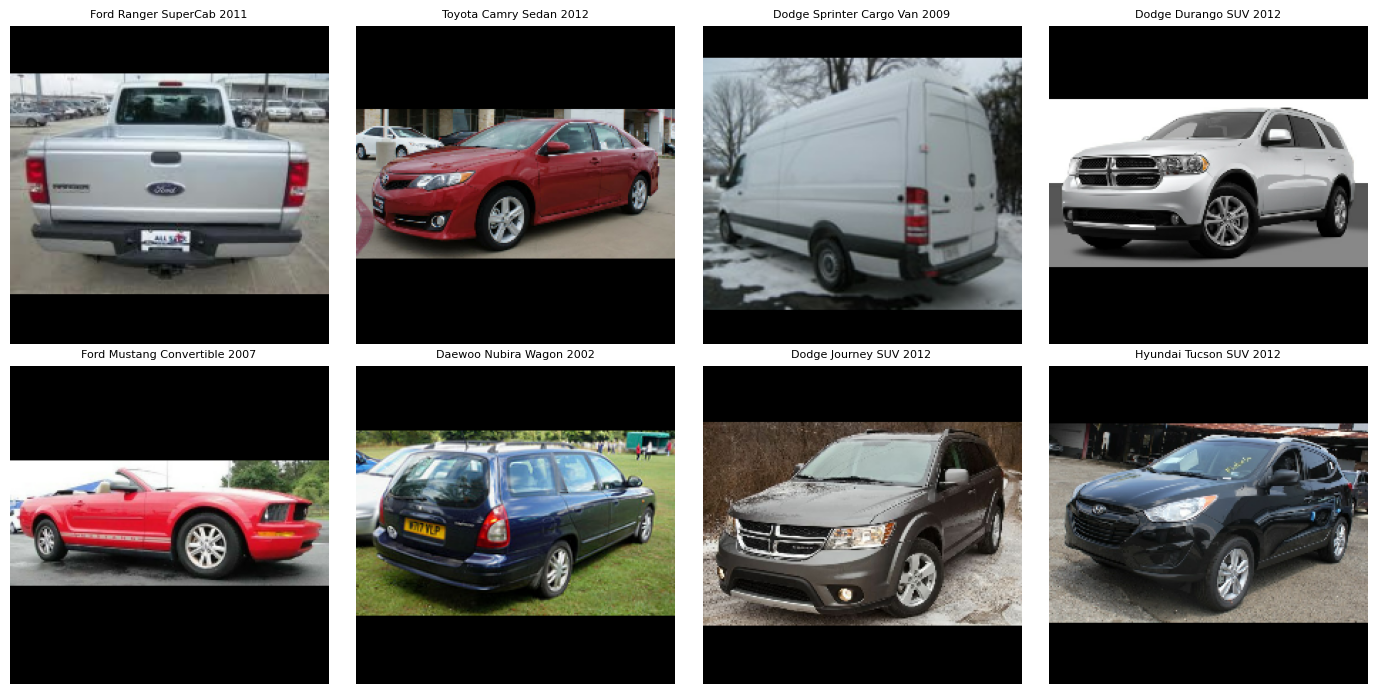

In [6]:
batch_images, batch_labels = next(iter(train_dataset))
print("Shape:", batch_images.shape)
print("Dtype:", batch_images.dtype)
print("Pixel range:", float(tf.reduce_min(batch_images)), float(tf.reduce_max(batch_images)))

figure, axes = plt.subplots(2, 4, figsize=(14, 7))
for axis, image, label in zip(axes.flat, batch_images[:8], batch_labels[:8]):
    axis.imshow(tf.cast(image, tf.uint8))
    axis.set_title(class_names[int(label)], fontsize=8)
    axis.axis("off")
plt.tight_layout()

## 4. Transfer learning и augmentation

Аугментации имитируют допустимые изменения фотографии: зеркальный ракурс, небольшие повороты, масштабирование и контраст. Они применяются только во время обучения.

Batch Normalization в backbone на первом этапе оставляем в режиме inference (`training=False`), чтобы маленькие batch не испортили накопленные статистики ImageNet.

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(CONFIG.rotation_factor, fill_mode="constant"),
    tf.keras.layers.RandomZoom(height_factor=CONFIG.zoom_height_range, width_factor=CONFIG.zoom_width_range, fill_mode="constant"),
    tf.keras.layers.RandomContrast(CONFIG.contrast_factor),
], name="car_image_augmentation")

backbone = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, CONFIG.channels),
)
backbone.trainable = False

image_input = tf.keras.Input(shape=(*IMAGE_SIZE, CONFIG.channels), name="image")
features = data_augmentation(image_input)
features = backbone(features, training=False)
features = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(features)
features = tf.keras.layers.BatchNormalization(name="classification_batch_normalization")(features)
features = tf.keras.layers.Dropout(CONFIG.dropout_rate, name="classification_dropout")(features)
prediction_output = tf.keras.layers.Dense(
    len(class_names), activation="softmax", dtype="float32", name="class_probabilities"
)(features)

model = tf.keras.Model(image_input, prediction_output, name="stanford_cars_efficientnet_b0")


def compile_classifier(classifier, learning_rate):
    classifier.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="top1_accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        ],
    )


compile_classifier(model, CONFIG.head_learning_rate)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "stanford_cars_efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ car_image_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_batch_normaliza… │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 1280)           │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 196)            │       251,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,305,767 (16.43 MB)

 Trainable params: 253,636 (990.77 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 5. Обучение классификационной головы

Checkpoint сохраняет лучший validation top-1, а не последний epoch. Early stopping предотвращает лишнее дообучение после прекращения улучшений. ReduceLROnPlateau уменьшает шаг оптимизатора, когда validation loss перестаёт снижаться.

In [8]:
CONFIG.output_directory.mkdir(parents=True, exist_ok=True)
head_model_path = CONFIG.output_directory / "best_head_model.keras"
head_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(head_model_path, monitor="val_top1_accuracy", mode="max", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_top1_accuracy", mode="max", patience=CONFIG.head_patience, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=CONFIG.reduce_lr_factor, patience=CONFIG.reduce_lr_patience, min_lr=CONFIG.head_min_learning_rate),
    tf.keras.callbacks.CSVLogger(CONFIG.output_directory / "head_training_log.csv"),
]

head_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CONFIG.head_epochs,
    callbacks=head_callbacks,
)

Epoch 1/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 67s 222ms/step - loss: 4.5584 - top1_accuracy: 0.1048 - top5_accuracy: 0.2637 - val_loss: 3.5681 - val_top1_accuracy: 0.2568 - val_top5_accuracy: 0.5491 - learning_rate: 0.0010
Epoch 2/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - loss: 2.8054 - top1_accuracy: 0.3325 - top5_accuracy: 0.6256 - val_loss: 2.6444 - val_top1_accuracy: 0.3612 - val_top5_accuracy: 0.6634 - learning_rate: 0.0010
Epoch 3/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - loss: 2.1806 - top1_accuracy: 0.4480 - top5_accuracy: 0.7418 - val_loss: 2.2859 - val_top1_accuracy: 0.4226 - val_top5_accuracy: 0.7285 - learning_rate: 0.0010
Epoch 4/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 37s 158ms/step - loss: 1.8003 - top1_accuracy: 0.5311 - top5_accuracy: 0.8196 - val_loss: 2.2387 - val_top1_accuracy: 0.4300 - val_top5_accuracy: 0.7568 - learning_rate: 0.0010
Epoch 5/12
204/204 ━━━━━━━━━━━━━━━━━━━━ 42s 164ms/step - loss: 1.5523 - top1_accuracy: 0.5940 - top5_accuracy: 0.8542 - val_loss: 2.

## 6. Fine-tuning последних слоёв

После обучения головы размораживаем только последние `fine_tune_layer_count` слоёв. Нижние слои кодируют общие края и текстуры, верхние — более специфические формы. Маленький learning rate нужен, чтобы новые признаки адаптировались без резкого разрушения предобученных весов. Batch Normalization оставляем замороженными.

In [9]:
model = tf.keras.models.load_model(head_model_path)
backbone = model.get_layer("efficientnetb0")
backbone.trainable = True

for layer in backbone.layers[:-CONFIG.fine_tune_layer_count]:
    layer.trainable = False
for layer in backbone.layers[-CONFIG.fine_tune_layer_count:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

compile_classifier(model, CONFIG.fine_tune_learning_rate)
fine_tuned_model_path = CONFIG.output_directory / "best_fine_tuned_model.keras"
fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(fine_tuned_model_path, monitor="val_top1_accuracy", mode="max", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_top1_accuracy", mode="max", patience=CONFIG.fine_tune_patience, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=CONFIG.reduce_lr_factor, patience=CONFIG.reduce_lr_patience, min_lr=CONFIG.fine_tune_min_learning_rate),
]

fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=CONFIG.fine_tune_epochs,
    callbacks=fine_tune_callbacks,
)

Epoch 1/8
204/204 ━━━━━━━━━━━━━━━━━━━━ 49s 182ms/step - loss: 0.6871 - top1_accuracy: 0.8071 - top5_accuracy: 0.9676 - val_loss: 1.8821 - val_top1_accuracy: 0.5356 - val_top5_accuracy: 0.8182 - learning_rate: 1.0000e-05
Epoch 2/8
204/204 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - loss: 0.6252 - top1_accuracy: 0.8232 - top5_accuracy: 0.9690 - val_loss: 1.8573 - val_top1_accuracy: 0.5430 - val_top5_accuracy: 0.8219 - learning_rate: 1.0000e-05
Epoch 3/8
204/204 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - loss: 0.6381 - top1_accuracy: 0.8226 - top5_accuracy: 0.9665 - val_loss: 1.8368 - val_top1_accuracy: 0.5491 - val_top5_accuracy: 0.8231 - learning_rate: 1.0000e-05
Epoch 4/8
204/204 ━━━━━━━━━━━━━━━━━━━━ 35s 173ms/step - loss: 0.5945 - top1_accuracy: 0.8316 - top5_accuracy: 0.9693 - val_loss: 1.8211 - val_top1_accuracy: 0.5553 - val_top5_accuracy: 0.8280 - learning_rate: 1.0000e-05
Epoch 5/8
204/204 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - loss: 0.5943 - top1_accuracy: 0.8339 - top5_accuracy: 0.9707 - v

## 7. Финальная оценка

Test set не участвовал в выборе checkpoint и hyperparameters. Поэтому эти метрики — наиболее честная оценка обобщающей способности модели. Разница между top-1 и top-5 показывает, насколько часто правильный класс попадает в короткий список кандидатов.

In [10]:
best_model_path = fine_tuned_model_path if fine_tuned_model_path.exists() else head_model_path
model = tf.keras.models.load_model(best_model_path)
test_metrics = model.evaluate(test_dataset, return_dict=True)
print({name: round(float(value), 4) for name, value in test_metrics.items()})

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 1.9566 - top1_accuracy: 0.5252 - top5_accuracy: 0.8209
{'loss': 1.9566, 'top1_accuracy': 0.5252, 'top5_accuracy': 0.8209}


## 8. Inference и отказ от неуверенных предсказаний

Одной максимальной вероятности недостаточно: softmax обязан суммироваться в 1 и может быть уверенным на изображении, которого нет среди поддерживаемых классов. Поэтому принимаем результат только если:

1. top-1 confidence выше `confidence_threshold`;
2. разница между top-1 и top-2 выше `margin_threshold`.

При отказе возвращаем `Unknown / unsupported`, а top-5 сохраняем для диагностики.

In [11]:
def prepare_uploaded_image(pil_image):
    image_array = np.asarray(pil_image.convert("RGB"), dtype=np.float32)
    return tf.image.resize_with_pad(image_array, CONFIG.image_height, CONFIG.image_width)


def predict_car(pil_image, top_k=None):
    top_k = CONFIG.top_k if top_k is None else top_k
    prepared_image = prepare_uploaded_image(pil_image)
    probabilities = model.predict(prepared_image[None, ...], verbose=0)[0]
    ranked_indices = np.argsort(probabilities)[::-1]
    best_index, second_index = int(ranked_indices[0]), int(ranked_indices[1])
    confidence = float(probabilities[best_index])
    margin = confidence - float(probabilities[second_index])
    accepted = confidence >= CONFIG.confidence_threshold and margin >= CONFIG.margin_threshold

    return {
        "accepted": accepted,
        "label": class_names[best_index] if accepted else "Unknown / unsupported",
        "confidence": confidence,
        "margin": margin,
        "top_predictions": [
            {"class_name": class_names[int(index)], "probability": float(probabilities[int(index)])}
            for index in ranked_indices[:top_k]
        ],
    }

In [12]:
sample_row = test_dataframe.sample(1, random_state=CONFIG.random_seed).iloc[0]
sample_image = Image.open(sample_row["image_path"]).convert("RGB")
prediction = predict_car(sample_image)
print(json.dumps(prediction, ensure_ascii=False, indent=2))

{
  "accepted": true,
  "label": "BMW M6 Convertible 2010",
  "confidence": 0.9808672070503235,
  "margin": 0.9690731819719076,
  "top_predictions": [
    {
      "class_name": "BMW M6 Convertible 2010",
      "probability": 0.9808672070503235
    },
    {
      "class_name": "BMW 6 Series Convertible 2007",
      "probability": 0.01179402507841587
    },
    {
      "class_name": "Ford Mustang Convertible 2007",
      "probability": 0.005775460507720709
    },
    {
      "class_name": "Audi RS 4 Convertible 2008",
      "probability": 0.000538488500751555
    },
    {
      "class_name": "Aston Martin Virage Convertible 2012",
      "probability": 0.0003724640409927815
    }
  ]
}


In [13]:
export_directory = CONFIG.output_directory / "fastapi_model_bundle"
export_directory.mkdir(parents=True, exist_ok=True)
exported_model_path = export_directory / "car_classifier.keras"
model.save(exported_model_path)

class_metadata = pd.DataFrame({
    "class_index": np.arange(len(class_names)),
    "class_name": class_names,
})
class_metadata.to_csv(export_directory / "class_metadata.csv", index=False)

inference_config = {
    "model_version": "1.0.0",
    "framework": "tensorflow",
    "tensorflow_version": tf.__version__,
    "image": {
        "height": CONFIG.image_height,
        "width": CONFIG.image_width,
        "channels": CONFIG.channels,
        "pixel_min": 0.0,
        "pixel_max": 255.0,
        "resize_method": "resize_with_pad",
        "color_mode": "RGB",
        "normalization": "inside_saved_efficientnet",
    },
    "classification": {
        "number_of_classes": len(class_names),
        "confidence_threshold": CONFIG.confidence_threshold,
        "margin_threshold": CONFIG.margin_threshold,
        "unknown_label": "Unknown / unsupported",
    },
}
with (export_directory / "inference_config.json").open("w", encoding="utf-8") as file:
    json.dump(inference_config, file, ensure_ascii=False, indent=2)

print("Bundle:", export_directory.resolve())
print("Model:", exported_model_path.stat().st_size / 1024**2, "MB")

Bundle: /content/artifacts/fastapi_model_bundle
Model: 30.503963470458984 MB
